# Notebook 4 — Feature Engineering
## Telecom Customer Retention Intelligence Platform

**Objective:** Create new features that capture business insights
discovered during EDA to improve model predictive power.

**Input:** data/raw/telco_churn.csv  
**Output:** data/processed/telco_churn_featured.csv  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## Load the data

In [3]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce'
)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 21)


## 2. New Feature — Tenure Group
Captures the insight that churn risk varies significantly
by customer lifecycle stage. First 12 months is highest risk.

In [4]:
def assign_tenure_group(tenure):
    if tenure <= 12:
        return 'Early'
    elif tenure <= 24:
        return 'Developing'
    elif tenure <= 48:
        return 'Established'
    else:
        return 'Loyal'

df['TenureGroup'] = df['tenure'].apply(assign_tenure_group)

print("Tenure Group distribution:")
print(df['TenureGroup'].value_counts())
print(f"\nChurn rate by Tenure Group:")
print(df.groupby('TenureGroup')['Churn'].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"
))

Tenure Group distribution:
TenureGroup
Loyal          2239
Early          2186
Established    1594
Developing     1024
Name: count, dtype: int64

Churn rate by Tenure Group:
TenureGroup
Developing     28.7%
Early          47.4%
Established    20.4%
Loyal           9.5%
Name: Churn, dtype: object


## 3. New Feature — Service Count
Counts how many services each customer subscribes to.
Hypothesis: more services = deeper engagement = lower churn.

Service Count distribution:
ServiceCount
1    1264
2     859
3     846
4     965
5     922
6     908
7     676
8     395
9     208
Name: count, dtype: int64


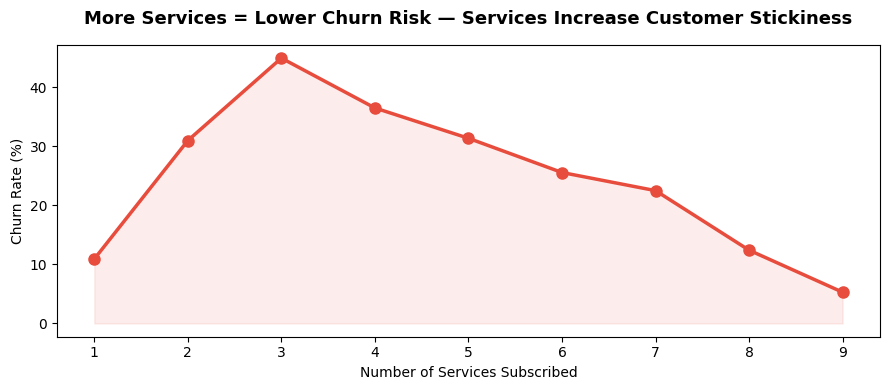

In [5]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] not in ['No', 'No phone service',
                             'No internet service']:
            count += 1
    return count

df['ServiceCount'] = df.apply(count_services, axis=1)

print("Service Count distribution:")
print(df['ServiceCount'].value_counts().sort_index())

# Visualize churn rate by service count
service_churn = df.groupby('ServiceCount')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
service_churn.columns = ['ServiceCount', 'ChurnRate']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(service_churn['ServiceCount'],
        service_churn['ChurnRate'],
        marker='o', color='#e74c3c',
        linewidth=2.5, markersize=8)

ax.fill_between(service_churn['ServiceCount'],
                service_churn['ChurnRate'],
                alpha=0.1, color='#e74c3c')

ax.set_title('More Services = Lower Churn Risk — '
             'Services Increase Customer Stickiness',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Services Subscribed')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(service_churn['ServiceCount'])

plt.tight_layout()
plt.savefig('../reports/churn_by_service_count.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 4. New Feature — Is High Risk
A rule-based binary flag combining the three strongest 
churn signals identified in EDA.

High Risk = Month-to-month contract 
            AND tenure under 12 months 
            AND monthly charges above $65

In [6]:
df['IsHighRisk'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] <= 12) &
    (df['MonthlyCharges'] > 65)
).astype(int)

high_risk_count = df['IsHighRisk'].sum()
high_risk_churn = df[df['IsHighRisk'] == 1]['Churn'].apply(
    lambda x: x == 'Yes'
).mean() * 100

print(f"High risk customers identified: {high_risk_count:,}")
print(f"Churn rate within high risk group: {high_risk_churn:.1f}%")
print(f"Overall churn rate: "
      f"{(df['Churn']=='Yes').mean()*100:.1f}%")
print(f"\nThis rule captures customers who are "
      f"{high_risk_churn/26.54:.1f}x more likely to churn")

High risk customers identified: 975
Churn rate within high risk group: 67.7%
Overall churn rate: 26.5%

This rule captures customers who are 2.6x more likely to churn


In [7]:
def charges_category(charge):
    if charge < 35:
        return 'Low'
    elif charge < 65:
        return 'Medium'
    else:
        return 'High'

df['ChargesCategory'] = df['MonthlyCharges'].apply(
    charges_category
)

print("Charges Category distribution:")
print(df['ChargesCategory'].value_counts())
print(f"\nChurn rate by Charges Category:")
print(df.groupby('ChargesCategory')['Churn'].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"
))

Charges Category distribution:
ChargesCategory
High      3904
Low       1731
Medium    1408
Name: count, dtype: int64

Churn rate by Charges Category:
ChargesCategory
High      34.7%
Low       10.9%
Medium    23.2%
Name: Churn, dtype: object


## 6. New Feature — Has Premium Services
Flags customers who have both streaming TV and 
streaming movies — premium entertainment subscribers.

In [8]:
df['HasPremiumServices'] = (
    (df['StreamingTV'] == 'Yes') &
    (df['StreamingMovies'] == 'Yes')
).astype(int)

premium_churn = df[df['HasPremiumServices'] == 1]['Churn'].apply(
    lambda x: x == 'Yes'
).mean() * 100

non_premium_churn = df[df['HasPremiumServices'] == 0]['Churn'].apply(
    lambda x: x == 'Yes'
).mean() * 100

print(f"Premium service customers: "
      f"{df['HasPremiumServices'].sum():,}")
print(f"Churn rate — Premium: {premium_churn:.1f}%")
print(f"Churn rate — Non-premium: {non_premium_churn:.1f}%")

Premium service customers: 1,940
Churn rate — Premium: 29.4%
Churn rate — Non-premium: 25.4%


## 7. Encode and Save Featured Dataset

In [9]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Drop customerID
df_model.drop(columns=['customerID'], inplace=True)

# Label encode binary columns
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling', 'SeniorCitizen', 'Churn'
]

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# One hot encode multi-category columns
ohe_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaymentMethod', 'TenureGroup', 'ChargesCategory'
]

df_model = pd.get_dummies(df_model, columns=ohe_cols,
                           drop_first=True)

print(f"Final featured dataset shape: {df_model.shape}")
print(f"Total features created: {df_model.shape[1] - 1}")

df_model.to_csv('../data/processed/telco_churn_featured.csv',
                index=False)
print("\nFeatured dataset saved to data/processed/")

Final featured dataset shape: (7043, 39)
Total features created: 38

Featured dataset saved to data/processed/
